In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import dgl
from glob import glob
from sklearn.model_selection import train_test_split

def load_data(input_folder, num_nodes):
    """Load phylogenetic graph data with self-loops."""
    node_files = glob(f"{input_folder}/*_node.csv")
    all_nodes = pd.concat([pd.read_csv(f) for f in node_files], ignore_index=True)
    
    node_counts = all_nodes.groupby('graph_id').size()
    valid_ids = [gid for gid in node_counts.index if node_counts[gid] == num_nodes]
    
    graphs = []
    for gid in valid_ids:
        node_df = all_nodes[all_nodes['graph_id'] == gid].sort_values('node').reset_index(drop=True)
        # Create graph with self-loops only
        g = dgl.graph((torch.arange(num_nodes), torch.arange(num_nodes)))
        
        for col in node_df.columns:
            if col not in ['graph_id', 'node']:
                g.ndata[col] = torch.tensor(node_df[col].values, dtype=torch.float32)
        g.graph_id = gid
        graphs.append(g)
    
    print(f"Loaded {len(graphs)} graphs with {num_nodes} nodes each (self-loops only)")
    return graphs

# Load and prepare data
graphs = load_data('/Users/lukelyu/Desktop/epidata/100_10_new/', num_nodes=10)

features = ['Initial_Population', 'Epidemic_Peak', 'Peak_Timing', 'Accumulated_Infections']
label = 'R0'

for g in graphs:
    g.ndata['feat'] = torch.stack([g.ndata[name] for name in features], dim=1)
    g.ndata['label'] = g.ndata[label]

# Train/val/test split
torch.manual_seed(42)
train_graphs, temp = train_test_split(graphs, test_size=0.3, random_state=42)
val_graphs, test_graphs = train_test_split(temp, test_size=0.5, random_state=42)

# Z-score normalization
for i, fname in enumerate(features):
    train_feat = torch.cat([g.ndata['feat'][:, i] for g in train_graphs])
    mean, std = train_feat.mean(), train_feat.std()
    
    for g in train_graphs + val_graphs + test_graphs:
        g.ndata['feat'][:, i] = (g.ndata['feat'][:, i] - mean) / std
    print(f"{fname}: Mean={mean:.2f}, Std={std:.2f}")

print(f"\nSplit: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

Loaded 500 graphs with 10 nodes each (self-loops only)
Initial_Population: Mean=5482.83, Std=2606.53
Epidemic_Peak: Mean=2058.60, Std=1064.90
Peak_Timing: Mean=140.84, Std=38.94
Accumulated_Infections: Mean=5406.47, Std=2705.01

Split: Train=350, Val=75, Test=75


## Experiment Strategy

Testing GCN (using DGL GraphConv) vs MLP on self-loop-only graphs to establish baseline before introducing real edges. This isolates the effect of graph structure on model performance.

In [10]:
from dgl.nn.pytorch import GraphConv

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=32):
        super().__init__()
        self.conv = GraphConv(in_dim, hidden_dim, norm='both', allow_zero_in_degree=True)
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, x):
        h = self.conv(g, x)
        return self.classifier(h).squeeze(-1)


class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, x):
        return self.layers(x).squeeze(-1)

In [11]:
def train_epoch(model, graphs, optimizer, criterion):
    model.train()
    total_loss = total_samples = 0
    
    for g in graphs:
        optimizer.zero_grad()
        loss = criterion(model(g, g.ndata['feat']), g.ndata['label'])
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * g.num_nodes()
        total_samples += g.num_nodes()
    
    return total_loss / total_samples


def evaluate(model, graphs, criterion):
    model.eval()
    total_loss = total_samples = 0
    
    with torch.no_grad():
        for g in graphs:
            loss = criterion(model(g, g.ndata['feat']), g.ndata['label'])
            total_loss += loss.item() * g.num_nodes()
            total_samples += g.num_nodes()
    
    return total_loss / total_samples


def train_model(model, name, epochs=300, patience=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters())}")
    
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_graphs, optimizer, criterion)
        val_loss = evaluate(model, val_graphs, criterion)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_state)
    test_loss = evaluate(model, test_graphs, criterion)
    print(f"Best Val: {best_val_loss:.6f} | Test: {test_loss:.6f}")
    
    return test_loss


# Train both models
in_dim = len(features)
gcn_model = GCN(in_dim, hidden_dim=32)
mlp_model = MLP(in_dim)

test_loss_gcn = train_model(gcn_model, "GCN")
test_loss_mlp = train_model(mlp_model, "MLP")

print(f"\n{'='*60}\nSummary\n{'='*60}")
print(f"GCN Test Loss: {test_loss_gcn:.6f}")
print(f"MLP Test Loss: {test_loss_mlp:.6f}")


Training GCN
Parameters: 433
Epoch  10 | Train: 0.172599 | Val: 0.146514
Epoch  20 | Train: 0.146196 | Val: 0.128724
Epoch  30 | Train: 0.135372 | Val: 0.123443
Epoch  40 | Train: 0.131616 | Val: 0.121545
Epoch  50 | Train: 0.128747 | Val: 0.120313
Epoch  60 | Train: 0.126516 | Val: 0.119922
Epoch  70 | Train: 0.125064 | Val: 0.119283
Epoch  80 | Train: 0.124055 | Val: 0.118936
Epoch  90 | Train: 0.122825 | Val: 0.118310
Epoch 100 | Train: 0.121968 | Val: 0.117648
Epoch 110 | Train: 0.121225 | Val: 0.117331
Epoch 120 | Train: 0.120660 | Val: 0.116915
Epoch 130 | Train: 0.120156 | Val: 0.116875
Epoch 140 | Train: 0.119451 | Val: 0.116649
Epoch 150 | Train: 0.118931 | Val: 0.116236
Epoch 160 | Train: 0.118238 | Val: 0.116039
Epoch 170 | Train: 0.117863 | Val: 0.116180
Epoch 180 | Train: 0.117481 | Val: 0.116225
Epoch 190 | Train: 0.116639 | Val: 0.116170
Epoch 200 | Train: 0.116000 | Val: 0.115670
Epoch 210 | Train: 0.116579 | Val: 0.115049
Epoch 220 | Train: 0.116066 | Val: 0.114961
Ep

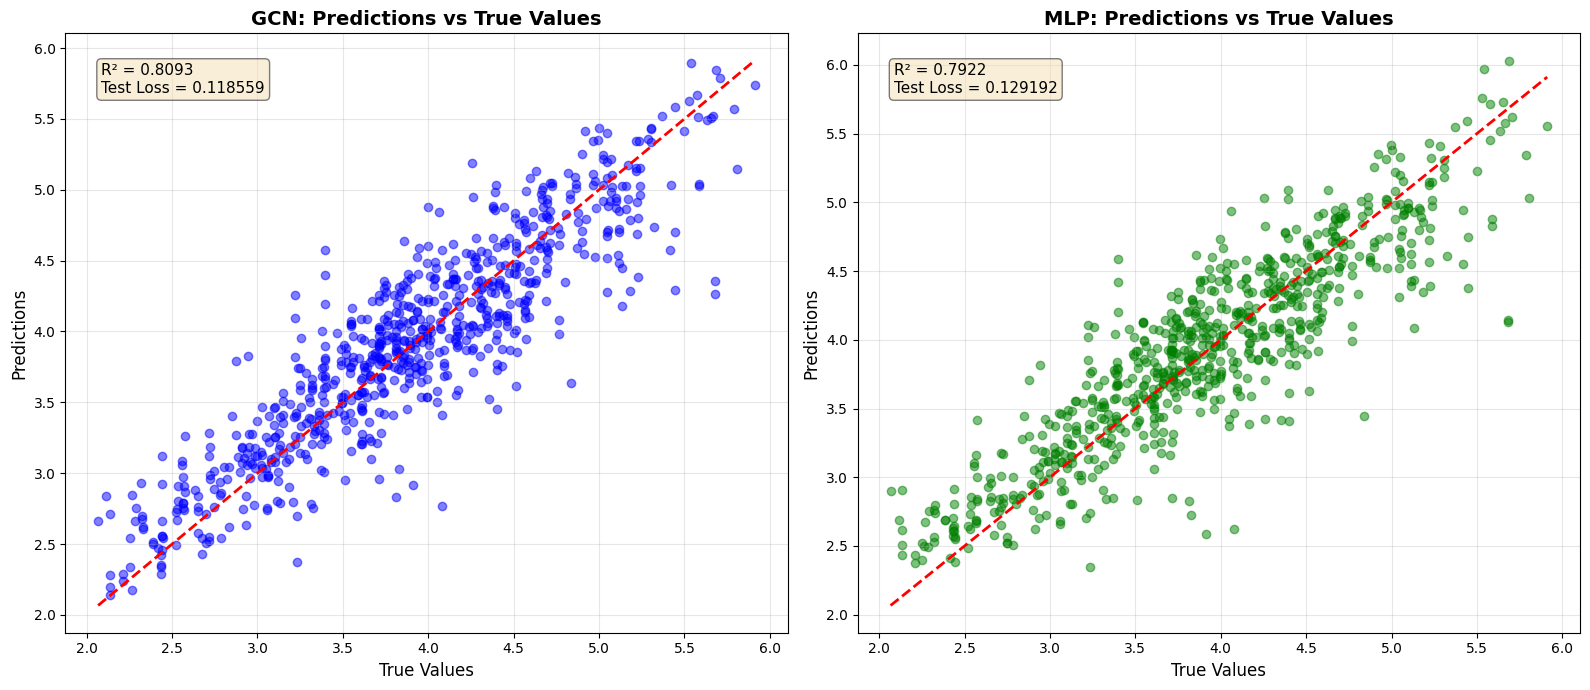

Model Comparison
GCN - R²: 0.8093, Loss: 0.118559
MLP - R²: 0.7922, Loss: 0.129192


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def get_predictions(model, graphs):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for g in graphs:
            preds.extend(model(g, g.ndata['feat']).cpu().numpy())
            labels.extend(g.ndata['label'].cpu().numpy())
    return np.array(preds), np.array(labels)

# Get predictions
gcn_preds, labels = get_predictions(gcn_model, test_graphs)
mlp_preds, _ = get_predictions(mlp_model, test_graphs)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, preds, name, loss, color in [
    (axes[0], gcn_preds, 'GCN', test_loss_gcn, 'blue'),
    (axes[1], mlp_preds, 'MLP', test_loss_mlp, 'green')
]:
    ax.scatter(labels, preds, alpha=0.5, color=color)
    ax.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--', lw=2)
    ax.set_xlabel('True Values', fontsize=12)
    ax.set_ylabel('Predictions', fontsize=12)
    ax.set_title(f'{name}: Predictions vs True Values', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    r2 = r2_score(labels, preds)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}\nTest Loss = {loss:.6f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"{'='*60}\nModel Comparison\n{'='*60}")
print(f"GCN - R²: {r2_score(labels, gcn_preds):.4f}, Loss: {test_loss_gcn:.6f}")
print(f"MLP - R²: {r2_score(labels, mlp_preds):.4f}, Loss: {test_loss_mlp:.6f}")